In [1]:
import torch
from unsloth import FastLanguageModel
from datasets import load_dataset
from transformers import TrainingArguments
from trl import SFTTrainer, DataCollatorForCompletionOnlyLM
from transformers import EarlyStoppingCallback
import json
import math
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
os.environ["UNSLOTH_COMPILE_DISABLE"] = "1"
torch._dynamo.config.disable = True

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [2]:
load_dotenv()
hf_token = os.getenv("HUGGINGFACE_HUB_TOKEN")

max_seq_length = 4048
dtype = None
load_in_4bit = True

In [3]:
model_path = r"D:\AMIT\AOU PROJECT\AOU Graduation Project\AOU-Graduation-Project\BioIntellect\AI\fintune\fintuned_chating_model\phi_medical_full_merged_16bit_chat"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name       = model_path,
    max_seq_length   = max_seq_length,
    dtype            = dtype,
    load_in_4bit     = load_in_4bit,
    token            = hf_token,
)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"
model.config.use_cache = False
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

==((====))==  Unsloth 2026.2.1: Fast Llama patching. Transformers: 4.57.3.
   \\   /|    NVIDIA GeForce RTX 3070 Ti Laptop GPU. Num GPUs = 1. Max memory: 8.0 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.5.1. CUDA: 8.6. CUDA Toolkit: 12.1. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [4]:
template_path = model_path + "/chat_template.jinja"

with open(template_path, "r", encoding="utf-8") as f:
    template = f.read()

tokenizer.chat_template = template
tokenizer.save_pretrained(model_path)

('D:\\AMIT\\AOU PROJECT\\AOU Graduation Project\\AOU-Graduation-Project\\BioIntellect\\AI\\fintune\\fintuned_chating_model\\phi_medical_full_merged_16bit_chat\\tokenizer_config.json',
 'D:\\AMIT\\AOU PROJECT\\AOU Graduation Project\\AOU-Graduation-Project\\BioIntellect\\AI\\fintune\\fintuned_chating_model\\phi_medical_full_merged_16bit_chat\\special_tokens_map.json',
 'D:\\AMIT\\AOU PROJECT\\AOU Graduation Project\\AOU-Graduation-Project\\BioIntellect\\AI\\fintune\\fintuned_chating_model\\phi_medical_full_merged_16bit_chat\\chat_template.jinja',
 'D:\\AMIT\\AOU PROJECT\\AOU Graduation Project\\AOU-Graduation-Project\\BioIntellect\\AI\\fintune\\fintuned_chating_model\\phi_medical_full_merged_16bit_chat\\tokenizer.model',
 'D:\\AMIT\\AOU PROJECT\\AOU Graduation Project\\AOU-Graduation-Project\\BioIntellect\\AI\\fintune\\fintuned_chating_model\\phi_medical_full_merged_16bit_chat\\added_tokens.json',
 'D:\\AMIT\\AOU PROJECT\\AOU Graduation Project\\AOU-Graduation-Project\\BioIntellect\\AI\

In [5]:
SYSTEM_PROMPT = """You must answer only using information explicitly provided in the user message. 
Do not add external knowledge. 
Do not assume missing facts. 
If the information is not present reply: "The context does not contain this information."
Maintain a neutral, clear, and factual tone (C2 English level)."""

In [6]:
test_instruction = (
    "Context:\n1.6 Anticoagulation (part 1)\n## 1.6 Stroke prevention\n\n### Anticoagulation\n\n- 1.6.1 When discussing the benefits and risks of anticoagulation use clinical risk profiles and personal preferences to guide treatment choices. Discuss with the person that:\n  - for most people the benefit of anticoagulation outweighs the bleeding risk\n  - for people with an increased risk of bleeding, the benefit of anticoagulation may not always outweigh the bleeding risk, and careful monitoring of bleeding risk is important. [2021]\n- 1.6.2 When deciding between anticoagulation treatment options:\n  - Discuss the risks and benefits of different drugs with the person and follow the recommendations in NICE's guideline on shared decision making.\n  - Follow the recommendations on patient involvement in decisions about medicines in NICE's guideline on medicines adherence and patient decision aids in NICE's guideline on medicines optimisation.\n  - Take into account any contraindications for each drug and follow the guidance in the British National Formulary and the MHRA advice on direct‑acting oral anticoagulants, in particular for advice on dosages in people with renal impairment, reversal agents and monitoring. [2021]\n- 1.6.3 Offer anticoagulation with a direct‑acting oral anticoagulant to people with atrial fibrillation and a CHA2DS2‑VASc score of 2 or above, taking into account the risk of bleeding. Apixaban, dabigatran, edoxaban and rivaroxaban are recommended as options, when used in line with the criteria specified in the relevant NICE technology appraisal guidance (see the section on direct‑acting oral anticoagulant treatment options). [2021]\n- 1.6.4 Consider anticoagulation with a direct‑acting oral anticoagulant for men with atrial fibrillation and a CHA2DS2‑VASc score of 1, taking into account the risk of bleeding. Apixaban, dabigatran, edoxaban and rivaroxaban are recommended as options, when used in line with the criteria specified in the relevant NICE technology appraisal guidance (see the section on direct‑acting oral anticoagulant treatment options). [2021]\n- 1.6.5 If direct‑acting oral anticoagulants are contraindicated, not tolerated or not suitable in people with atrial fibrillation, offer a vitamin K antagonist. See the section on self‑monitoring and self‑management of vitamin K antagonists. [2021]\n- 1.6.6 For adults with atrial fibrillation who are already taking a vitamin K antagonist and are stable, continue with their current medication and discuss the option of switching treatment at their next routine appointment, taking into account the person's time in therapeutic range. [2021]\n- 1.6.7 Do not offer stroke prevention therapy with anticoagulation to people aged under 65 years with atrial fibrillation and no risk factors other than their sex (that is, very low risk of stroke equating to a CHA2DS2‑VASc score of 0 for men or 1 for women). [2021]\n- 1.6.8 Do not withhold anticoagulation solely because of a person's age or their risk of falls. [2021]\n\nTask: Answer the following question based only on the context.\nQuestion: Which direct‑acting oral anticoagulant drugs are recommended as options?"
    
)

test_messages = [
    {"role": "system", "content": SYSTEM_PROMPT},
    {"role": "user",   "content": test_instruction},
]

test_text = tokenizer.apply_chat_template(
    test_messages,
    tokenize=False,
    add_generation_prompt=True,
)

inputs = tokenizer(test_text, return_tensors="pt").to(model.device)

outputs = model.generate(
    **inputs,
    max_new_tokens = 256,
    temperature    = 0.0,
    top_p          = 0.9,
    use_cache      = False,
)

generated = outputs[0]
prompt_len = inputs["input_ids"].shape[1]
answer_ids = generated[prompt_len:]

answer = tokenizer.decode(answer_ids, skip_special_tokens=True)
print("=== Model answer ===")
print(answer.strip())

=== Model answer ===
Apixaban, dabigatran, edoxaban, and rivaroxaban.


In [7]:
model = FastLanguageModel.get_peft_model(
    model,
    r=32,
    target_modules=[
        "q_proj","k_proj","v_proj","o_proj",
        "gate_proj","up_proj","down_proj",],
    lora_alpha=64,               
    lora_dropout=0.2,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
    use_rslora=True,             
    loftq_config=None)

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.2.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.2.1 patched 32 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


In [8]:
data_path = r"D:\AMIT\AOU PROJECT\AOU Graduation Project\AOU-Graduation-Project\BioIntellect\AI\fintune\data QA\instruction.json"

dataset = load_dataset("json",data_files=data_path,split="train")

dataset = dataset.train_test_split(test_size=0.1, seed=123123)
train_dataset = dataset["train"]
val_dataset   = dataset["test"]

print("train sample:", len(train_dataset))
print("val sample:", len(val_dataset))

train sample: 2616
val sample: 291


In [9]:
def format_chat_template_for_unsloth(batch, system_prompt):
    texts = []

    inputs       = batch["input"]
    outputs      = batch["output"]

    for  inp, out in zip( inputs, outputs):
        user_content = f"Input:\n{inp}"

        messages = [
            {"role": "system",    "content": system_prompt},
            {"role": "user",      "content": user_content},
            {"role": "assistant", "content": out},
        ]

        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
        )
        texts.append(text)

    return {"text": texts}

train_dataset = train_dataset.map(
    format_chat_template_for_unsloth,
    batched=True,
    fn_kwargs={"system_prompt": SYSTEM_PROMPT},

)

val_dataset = val_dataset.map(
    format_chat_template_for_unsloth,
    batched=True,
    fn_kwargs={"system_prompt": SYSTEM_PROMPT},

)

In [10]:
print(train_dataset[0]["text"][:500])

<|system|>
You must answer only using information explicitly provided in the user message. 
Do not add external knowledge. 
Do not assume missing facts. 
If the information is not present reply: "The context does not contain this information."
Maintain a neutral, clear, and factual tone (C2 English level).<|end|>
<|user|>
Input:
Context:
1.2 NSTEMI and unstable angina – Management when PCI is not indicated
## Management when PCI is not indicated

- 1.2.20 Consider conservative management without


In [ ]:
response_template = "<|assistant|>"

data_collator = DataCollatorForCompletionOnlyLM(
    tokenizer=tokenizer,
    response_template=response_template,
)
early_stopping = EarlyStoppingCallback(
    early_stopping_patience=1,   # يستنى كام eval متتالي من غير تحسن قبل ما يوقف
    early_stopping_threshold=0.0 # أقل تحسن محسوب، 0 يعني لازم يتحسن فعلاً
)
training_args = TrainingArguments(
    output_dir="phi-medical-af-qa-lora-r32_checkpoint",
    gradient_accumulation_steps=8,
    num_train_epochs=2,
    learning_rate=1e-5,

    per_device_train_batch_size=1,

    save_strategy="steps",
    save_steps=20,
    eval_strategy="steps",
    eval_steps=20,
    ddp_find_unused_parameters=False,

    load_best_model_at_end=True,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    weight_decay=0.01,
    max_grad_norm=1.0,

    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),

    logging_steps=20,
    report_to="none",
    seed=123123,
    optim="paged_adamw_8bit",
)


trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    dataset_text_field="text",
    max_seq_length=4048,
    packing=False,
    args=training_args,
    data_collator=data_collator,
    callbacks=[early_stopping],  
)

In [20]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,616 | Num Epochs = 2 | Total steps = 654
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 59,768,832 of 3,880,848,384 (1.54% trained)


Step,Training Loss,Validation Loss
20,0.356100,0.364256
40,0.303600,0.302209
60,0.290800,0.283421
80,0.271800,0.270871
100,0.273300,0.259286
120,0.253300,0.250413
140,0.240500,0.246690
160,0.227900,0.242897
180,0.228300,0.237871
200,0.230700,0.235910


Unsloth: Not an error, but LlamaForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


In [21]:
FastLanguageModel.for_inference(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32064, 3072, padding_idx=32009)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=3072, out_features=3072, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.2, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=3072, out_features=32, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=32, out_features=3072, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
          

In [22]:
model.save_pretrained("phi_medical_lora_adapters_model_QA")
tokenizer.save_pretrained("phi_medical_lora_adapters_tokenizer_QA")

('phi_medical_lora_adapters_tokenizer_QA\\tokenizer_config.json',
 'phi_medical_lora_adapters_tokenizer_QA\\special_tokens_map.json',
 'phi_medical_lora_adapters_tokenizer_QA\\chat_template.jinja',
 'phi_medical_lora_adapters_tokenizer_QA\\tokenizer.model',
 'phi_medical_lora_adapters_tokenizer_QA\\added_tokens.json',
 'phi_medical_lora_adapters_tokenizer_QA\\tokenizer.json')

In [23]:
model.save_pretrained_merged("phi_medical_full_merged_16bit_QA",tokenizer,save_method="merged_16bit")

Detected local model directory: D:\AMIT\AOU PROJECT\AOU Graduation Project\AOU-Graduation-Project\BioIntellect\AI\fintune\fintuned_chating_model\phi_medical_full_merged_16bit_chat
Copied tokenizer.model from local model directory
Found HuggingFace hub cache directory: C:\Users\Legion\.cache\huggingface\hub


Unsloth: Preparing safetensor model files:  50%|█████     | 1/2 [00:04<00:04,  5.00s/it]

Copied model-00001-of-00002.safetensors from local model directory


Unsloth: Preparing safetensor model files: 100%|██████████| 2/2 [00:07<00:00,  3.74s/it]


Copied model-00002-of-00002.safetensors from local model directory


Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [00:15<00:00,  7.71s/it]


Unsloth: Merge process complete. Saved to `d:\AMIT\AOU PROJECT\AOU Graduation Project\AOU-Graduation-Project\BioIntellect\AI\fintune\phi_medical_full_merged_16bit_QA`


In [24]:
test_instruction = (
    "Context:\n1.6 Anticoagulation (part 1)\n## 1.6 Stroke prevention\n\n### Anticoagulation\n\n- 1.6.1 When discussing the benefits and risks of anticoagulation use clinical risk profiles and personal preferences to guide treatment choices. Discuss with the person that:\n  - for most people the benefit of anticoagulation outweighs the bleeding risk\n  - for people with an increased risk of bleeding, the benefit of anticoagulation may not always outweigh the bleeding risk, and careful monitoring of bleeding risk is important. [2021]\n- 1.6.2 When deciding between anticoagulation treatment options:\n  - Discuss the risks and benefits of different drugs with the person and follow the recommendations in NICE's guideline on shared decision making.\n  - Follow the recommendations on patient involvement in decisions about medicines in NICE's guideline on medicines adherence and patient decision aids in NICE's guideline on medicines optimisation.\n  - Take into account any contraindications for each drug and follow the guidance in the British National Formulary and the MHRA advice on direct‑acting oral anticoagulants, in particular for advice on dosages in people with renal impairment, reversal agents and monitoring. [2021]\n- 1.6.3 Offer anticoagulation with a direct‑acting oral anticoagulant to people with atrial fibrillation and a CHA2DS2‑VASc score of 2 or above, taking into account the risk of bleeding. Apixaban, dabigatran, edoxaban and rivaroxaban are recommended as options, when used in line with the criteria specified in the relevant NICE technology appraisal guidance (see the section on direct‑acting oral anticoagulant treatment options). [2021]\n- 1.6.4 Consider anticoagulation with a direct‑acting oral anticoagulant for men with atrial fibrillation and a CHA2DS2‑VASc score of 1, taking into account the risk of bleeding. Apixaban, dabigatran, edoxaban and rivaroxaban are recommended as options, when used in line with the criteria specified in the relevant NICE technology appraisal guidance (see the section on direct‑acting oral anticoagulant treatment options). [2021]\n- 1.6.5 If direct‑acting oral anticoagulants are contraindicated, not tolerated or not suitable in people with atrial fibrillation, offer a vitamin K antagonist. See the section on self‑monitoring and self‑management of vitamin K antagonists. [2021]\n- 1.6.6 For adults with atrial fibrillation who are already taking a vitamin K antagonist and are stable, continue with their current medication and discuss the option of switching treatment at their next routine appointment, taking into account the person's time in therapeutic range. [2021]\n- 1.6.7 Do not offer stroke prevention therapy with anticoagulation to people aged under 65 years with atrial fibrillation and no risk factors other than their sex (that is, very low risk of stroke equating to a CHA2DS2‑VASc score of 0 for men or 1 for women). [2021]\n- 1.6.8 Do not withhold anticoagulation solely because of a person's age or their risk of falls. [2021]\n\nTask: Answer the following question based only on the context.\nQuestion: Which direct‑acting oral anticoagulant drugs are recommended as options?"
    
)

test_messages = [
    {"role": "system", "content": SYSTEM_PROMPT},
    {"role": "user",   "content": test_instruction},
]

test_text = tokenizer.apply_chat_template(
    test_messages,
    tokenize=False,
    add_generation_prompt=True,
)

inputs = tokenizer(test_text, return_tensors="pt").to(model.device)

outputs = model.generate(
    **inputs,
    max_new_tokens = 256,
    temperature    = 0.0,
    top_p          = 0.9,
    use_cache      = False,
)

generated = outputs[0]
prompt_len = inputs["input_ids"].shape[1]
answer_ids = generated[prompt_len:]

answer = tokenizer.decode(answer_ids, skip_special_tokens=True)
print("=== Model answer ===")
print(answer.strip())

=== Model answer ===
Apixaban, dabigatran, edoxaban and rivaroxaban are recommended as options.
Evidence: "Apixaban, dabigatran, edoxaban and rivaroxaban are recommended as options"


In [25]:
import math

train_metrics = trainer.evaluate(eval_dataset=trainer.train_dataset)
val_metrics   = trainer.evaluate() 

train_metrics["ppl"] = math.exp(train_metrics["eval_loss"])
val_metrics["ppl"]   = math.exp(val_metrics["eval_loss"])

train_metrics, val_metrics

({'eval_loss': 0.21205930411815643,
  'eval_runtime': 900.0922,
  'eval_samples_per_second': 2.906,
  'eval_steps_per_second': 0.363,
  'epoch': 0.672782874617737,
  'ppl': 1.2362211959125347},
 {'eval_loss': 0.23598414659500122,
  'eval_runtime': 91.4842,
  'eval_samples_per_second': 3.181,
  'eval_steps_per_second': 0.404,
  'epoch': 0.672782874617737,
  'ppl': 1.266154237151855})

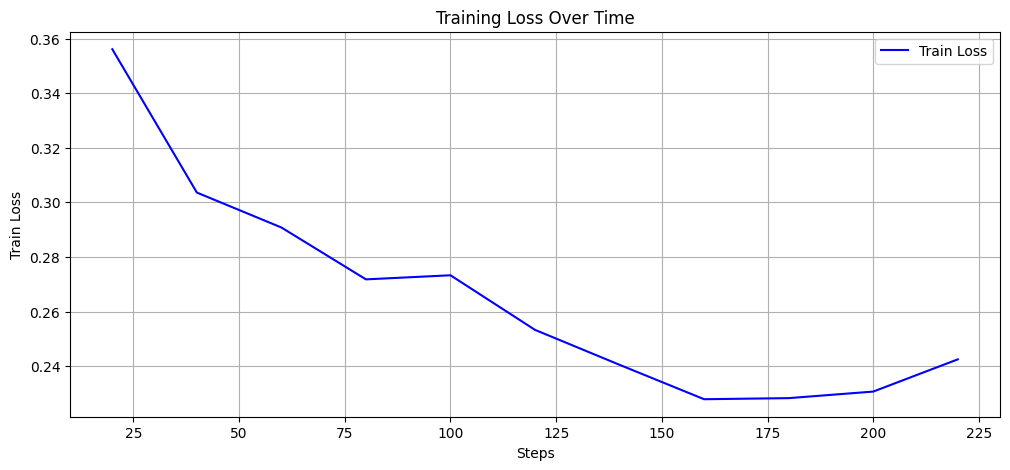

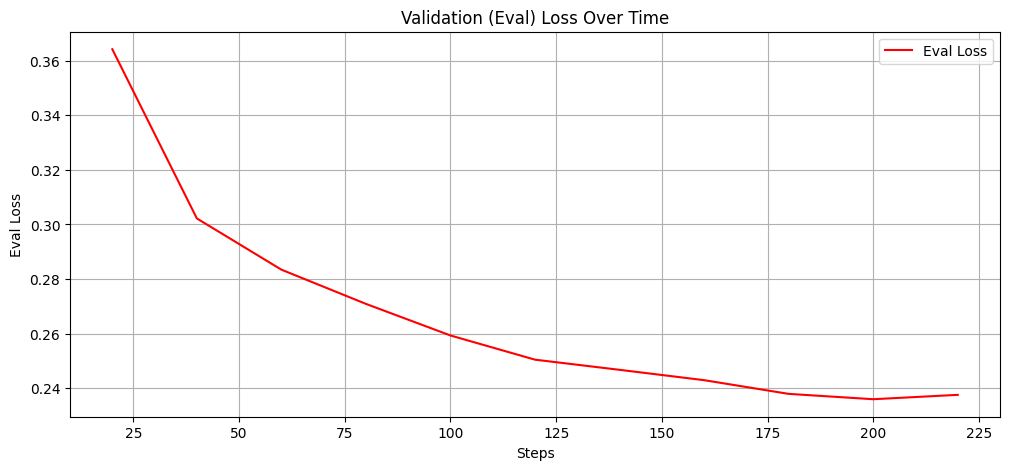

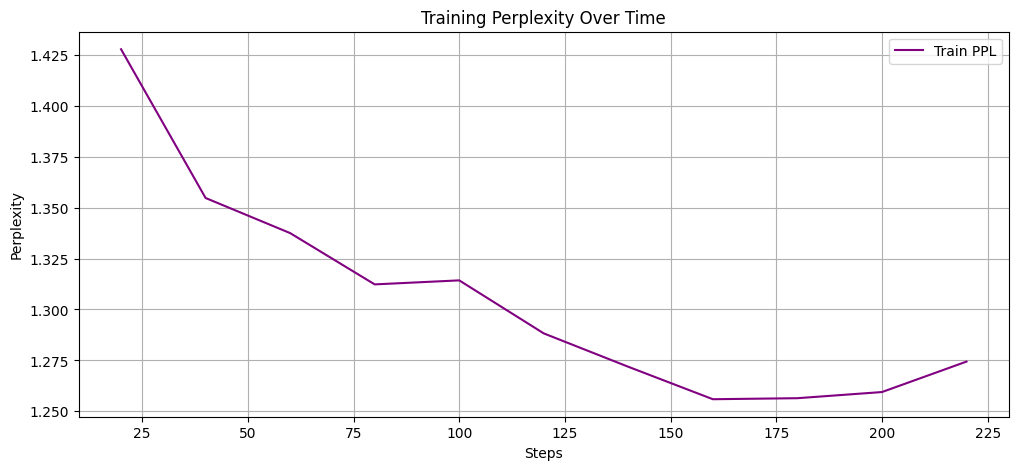

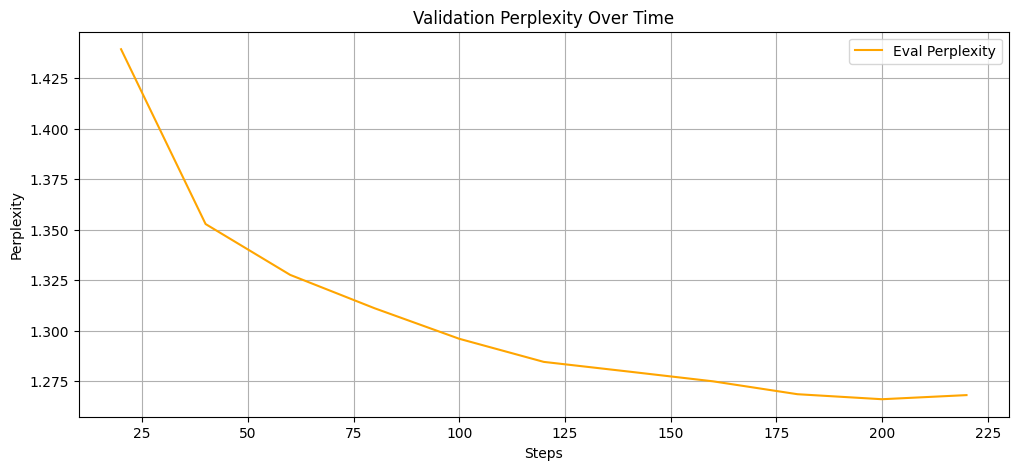

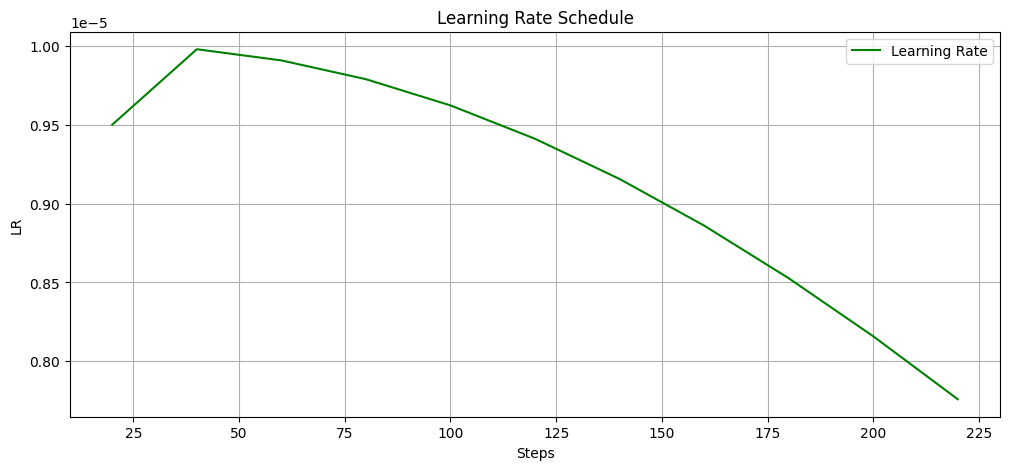

In [27]:
state_path = r"D:\AMIT\AOU PROJECT\AOU Graduation Project\AOU-Graduation-Project\BioIntellect\AI\fintune\phi-medical-af-qa-lora-r32_checkpoint\checkpoint-220\trainer_state.json"

with open(state_path, "r") as f:
    state = json.load(f)

log_history = state["log_history"]


steps = []
train_losses = []
train_ppl = []
learning_rates = []

eval_steps = []
eval_losses = []
eval_ppl = []

for e in log_history:
    if "loss" in e:
        steps.append(e["step"])
        train_losses.append(e["loss"])
        train_ppl.append(math.exp(e["loss"]))
        learning_rates.append(e.get("learning_rate", None))
        
    if "eval_loss" in e:
        eval_steps.append(e["step"])
        eval_losses.append(e["eval_loss"])
        eval_ppl.append(math.exp(e["eval_loss"]))



plt.figure(figsize=(12, 5))
plt.plot(steps, train_losses, label="Train Loss", color="blue")
plt.title("Training Loss Over Time")
plt.xlabel("Steps")
plt.ylabel("Train Loss")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(12, 5))
plt.plot(eval_steps, eval_losses, label="Eval Loss", color="red")
plt.title("Validation (Eval) Loss Over Time")
plt.xlabel("Steps")
plt.ylabel("Eval Loss")
plt.grid(True)
plt.legend()
plt.show()



plt.figure(figsize=(12, 5))
plt.plot(steps, train_ppl, label="Train PPL", color="purple")
plt.title("Training Perplexity Over Time")
plt.xlabel("Steps")
plt.ylabel("Perplexity")
plt.grid(True)
plt.legend()
plt.show()



plt.figure(figsize=(12, 5))
plt.plot(eval_steps, eval_ppl, label="Eval Perplexity", color="orange")
plt.title("Validation Perplexity Over Time")
plt.xlabel("Steps")
plt.ylabel("Perplexity")
plt.grid(True)
plt.legend()
plt.show()



lr_steps = [s for s, lr in zip(steps, learning_rates) if lr is not None]
lr_values = [lr for lr in learning_rates if lr is not None]

plt.figure(figsize=(12, 5))
plt.plot(lr_steps, lr_values, color="green", label="Learning Rate")
plt.title("Learning Rate Schedule")
plt.xlabel("Steps")
plt.ylabel("LR")
plt.grid(True)
plt.legend()
plt.show()
